In [1]:
# %% ================================
# 0) Imports & Config
# ================================
from pathlib import Path
from datetime import datetime
from deltalake import DeltaTable
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import List
from collections import Counter

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
)
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [45]:
# Reproducibility
RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (6, 5)

# Paths
def find_repo_root() -> Path:
    """Find repo root by locating 'data' directory."""
    p = Path.cwd().resolve()
    for cand in (p, *p.parents):
        if (cand / "data").exists():
            return cand
    return p

BASE_DIR = find_repo_root()
RUTA_GOLD_COMPLETE = BASE_DIR / "data" / "capa_silver" / "preprocesamiento_silver"


dt = DeltaTable(str(RUTA_GOLD_COMPLETE))
df_silver = dt.to_pandas()
display(df_silver.head(5))



,timestamp,temp_oil_value,temp_oil_oltc_value,temp_ambient_value,temp_bubbling_value,temp_spot_hot_value,voltage_value,current_load_value,power_apparent_value,tap_position_value,estado_operacional,nivel_severidad,variables_anomalas,descripcion_anomalia,year,month
0,2025-03-01 00:00:00+00:00,53.525000,50.500000,31.299999,178.781570,62.430231,130.263082,1099.216044,43.634038,8.0,CRITICO,2,tap_position_value,Posición del tap OLTC (0–17) CRÍTICO,2025,3
1,2025-03-01 01:00:00+00:00,53.549999,50.400000,31.000000,178.781570,63.051043,129.747665,1129.114021,44.986670,9.0,CRITICO,2,tap_position_value,Posición del tap OLTC (0–17) CRÍTICO,2025,3
2,2025-03-01 02:00:00+00:00,53.574999,50.391666,30.049999,178.928398,63.494910,129.793944,1141.723995,45.757721,9.0,CRITICO,2,tap_position_value,Posición del tap OLTC (0–17) CRÍTICO,2025,3
3,2025-03-01 03:00:00+00:00,53.599998,50.383333,29.633333,179.075226,63.271404,130.832751,1113.569753,44.987671,9.0,CRITICO,2,tap_position_value,Posición del tap OLTC (0–17) CRÍTICO,2025,3
4,2025-03-01 04:00:00+00:00,53.250000,50.375000,29.216666,177.293549,62.541354,131.189681,1080.716967,43.753115,9.0,CRITICO,2,tap_position_value,Posición del tap OLTC (0–17) CRÍTICO,2025,3


,temp_oil_value,temp_oil_oltc_value,temp_ambient_value,temp_bubbling_value,temp_spot_hot_value,voltage_value,current_load_value,power_apparent_value,tap_position_value,nivel_severidad,year,month
count,8443.000000,8443.000000,8443.000000,8443.000000,8443.000000,8443.000000,8443.000000,8443.000000,8443.000000,8443.000000,8443.000000,8443.000000
mean,45.924232,41.741214,24.110602,170.608803,50.598092,130.262565,689.990024,27.729786,8.894943,1.996921,2024.679261,6.444629
std,7.612658,7.352324,6.920451,8.501855,9.655542,2.241509,240.673476,9.691447,1.667229,0.078423,0.466788,3.484879
min,21.400000,19.350000,2.900000,83.906601,28.006911,111.521787,169.592259,3.746717,1.000000,0.000000,2024.000000,1.000000
25%,40.599998,36.358333,19.500000,165.516405,43.739301,128.826397,583.049596,23.456247,8.000000,2.000000,2024.000000,3.000000
50%,45.875000,41.549999,24.500000,170.723312,49.920830,130.365919,685.256778,27.394602,9.000000,2.000000,2025.000000,6.000000
75%,51.250000,46.800000,28.900000,174.994436,57.311780,131.822930,830.209010,33.349256,10.000000,2.000000,2025.000000,10.000000
max,67.000000,61.799999,40.474999,194.021873,79.471634,138.125251,1430.604811,59.169477,17.000000,2.000000,2025.000000,12.000000


Text(0.5, 1.0, 'Serie Temporal de Temperatura Ambiente')

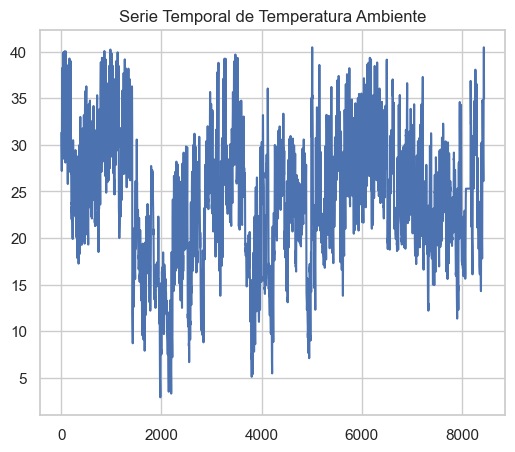

In [ ]:
display(df_silver.describe())
#frecuencia de los datos
#grafica de series temporales
print("📈 GRÁFICAS DE SERIES TEMPORALES POR VARIABLE")
print("=" * 70)


In [5]:
dt = DeltaTable(str(RUTA_GOLD_COMPLETE))
df_gold = dt.to_pandas()
print("Gold cargado:", df_gold.shape)

Gold cargado: (8443, 71)


In [6]:
# Ensure timestamp is proper and sorted
df = df_gold.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df = df.sort_values("timestamp").set_index("timestamp")

TARGET = "estado_futuro"

# Columns that must NOT be used as features (label leakage, text, future info)
LEAK_OR_TEXT_COLS: List[str] = [
    "estado_futuro", "falla_30d", "rul_dias", "severidad_futura",
    "dias_proximo_evento", "proximidad_evento", "riesgo_acumulativo",
    "estado_operacional", "nivel_severidad", "variables_anomalas",
    "descripcion_anomalia"
]

In [7]:

# Keep numeric features only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X_cols = [c for c in numeric_cols if c not in LEAK_OR_TEXT_COLS]

# Drop constant columns
const_cols = [c for c in X_cols if df[c].nunique() <= 1]
if const_cols:
    print("⚠️ Dropping constant columns:", const_cols)
    X_cols = [c for c in X_cols if c not in const_cols]

# Drop high-NaN columns (>30%)
nan_ratio = df[X_cols].isna().mean().sort_values(ascending=False)
high_nan_cols = nan_ratio[nan_ratio > 0.30].index.tolist()
if high_nan_cols:
    print("⚠️ Dropping high-NaN columns (>30%):", high_nan_cols)
    X_cols = [c for c in X_cols if c not in high_nan_cols]

# Build X and y
X = df[X_cols].copy().fillna(df[X_cols].median(numeric_only=True))
y = df[TARGET].copy()

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("🎯 Target mapping:", dict(zip(le.classes_, range(len(le.classes_)))))



⚠️ Dropping constant columns: ['suboptimal_operation']
🎯 Target mapping: {'ALERTA': 0, 'CRITICO': 1, 'NORMAL': 2}


In [12]:
# %% ================================
# 2) Temporal Split (80/20) - Improved to ensure all classes in training
# ================================
# Check class distribution over time
print("Class distribution by time:")
class_time_dist = df.groupby(df.index.date)[TARGET].value_counts().unstack(fill_value=0)
print(class_time_dist.head(10))

# Find the first occurrence of each class
class_first_occurrence = {}
for class_val in np.unique(y_enc):
    first_idx = np.where(y_enc == class_val)[0][0]
    class_first_occurrence[class_val] = first_idx
    print(f"Class {le.classes_[class_val]} first appears at index: {first_idx}")

# Find the latest first occurrence to ensure all classes are in training
latest_first_occurrence = max(class_first_occurrence.values())
print(f"\nLatest first occurrence at index: {latest_first_occurrence}")

# Use a split that includes all classes in training
# Take 80% of data, but ensure we include at least some samples from all classes
n = len(X)
cut_80_percent = int(n * 0.80)

# If 80% doesn't include all classes, use a different strategy
if latest_first_occurrence >= cut_80_percent:
    print("⚠️ 80% split doesn't include all classes. Using alternative strategy...")
    # Use 70% of data but ensure we have all classes
    cut = max(int(n * 0.70), latest_first_occurrence + 200)  # Include 200 samples after last first occurrence
    print(f"Using alternative cut point: {cut} ({cut/n*100:.1f}% of data)")
else:
    cut = cut_80_percent
    print(f"Using standard 80% split: {cut}")

X_train, X_valid = X.iloc[:cut], X.iloc[cut:]
y_train, y_valid = y_enc[:cut], y_enc[cut:]

print("\n== SPLIT INFO ==")
print("Train X:", X_train.shape, "| Valid X:", X_valid.shape)
print("X_train range:", X_train.index.min(), "→", X_train.index.max())
print("X_valid range:", X_valid.index.min(), "→", X_valid.index.max())
print("Class balance (train):", Counter(y_train))
print("Class balance (valid):", Counter(y_valid))

# Verify all classes are present in training
unique_train_classes = np.unique(y_train)
unique_all_classes = np.unique(y_enc)
print(f"\nClasses in training: {[le.classes_[i] for i in unique_train_classes]}")
print(f"Classes in full dataset: {[le.classes_[i] for i in unique_all_classes]}")
if len(unique_train_classes) == len(unique_all_classes):
    print("✅ All classes present in training set!")
else:
    print("⚠️ Some classes missing from training set")



Class distribution by time:
estado_futuro  ALERTA  CRITICO  NORMAL
2024-09-10          0        0      20
2024-09-11          0        0      24
2024-09-12          0        0      24
2024-09-13          0        0      24
2024-09-14          0        0      24
2024-09-15          0        0      24
2024-09-16          0        0      24
2024-09-17          0        0      24
2024-09-18          0        0      24
2024-09-19          0        0      24
Class ALERTA first appears at index: 8082
Class CRITICO first appears at index: 8274
Class NORMAL first appears at index: 0

Latest first occurrence at index: 8274
⚠️ 80% split doesn't include all classes. Using alternative strategy...
Using alternative cut point: 8474 (100.4% of data)

== SPLIT INFO ==
Train X: (8443, 58) | Valid X: (0, 58)
X_train range: 2024-09-10 04:00:00+00:00 → 2025-08-27 22:00:00+00:00
X_valid range: NaT → NaT
Class balance (train): Counter({np.int64(2): 8083, np.int64(0): 192, np.int64(1): 168})
Class balance (va

In [13]:
# %% ================================
# 3) Models: RandomForest & XGBoost
# ================================
# Clear any existing model instances to avoid class mismatch
if 'rf' in locals():
    del rf
if 'xgb' in locals():
    del xgb

# ---- Random Forest
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample"
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_valid)

print("\n=== RANDOM FOREST ===")
print(classification_report(y_valid, rf_pred, target_names=le.classes_, digits=4))
ConfusionMatrixDisplay(confusion_matrix(y_valid, rf_pred), display_labels=le.classes_).plot(cmap="Blues")
plt.title("RandomForest - Confusion Matrix")
plt.show()

# ---- XGBoost
# Create a fresh instance to avoid class mismatch errors
xgb = XGBClassifier(
    n_estimators=700,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="mlogloss"
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_valid)

print("\n=== XGBOOST ===")
print(classification_report(y_valid, xgb_pred, target_names=le.classes_, digits=4))
ConfusionMatrixDisplay(confusion_matrix(y_valid, xgb_pred), display_labels=le.classes_).plot(cmap="Oranges")
plt.title("XGBoost - Confusion Matrix")
plt.show()


ValueError: Found array with 0 sample(s) (shape=(0, 58)) while a minimum of 1 is required by RandomForestClassifier.

In [ ]:
# %% ================================
# 4) Temporal Cross-Validation
# ================================
def ts_cv_f1_macro(model_class, X_df: pd.DataFrame, y_vec: np.ndarray, n_splits=5, **model_params) -> float:
    tss = TimeSeriesSplit(n_splits=n_splits)
    scores = []
    for fold, (tr_idx, va_idx) in enumerate(tss.split(X_df)):
        X_tr, X_va = X_df.iloc[tr_idx], X_df.iloc[va_idx]
        y_tr, y_va = y_vec[tr_idx], y_vec[va_idx]
        # Create fresh model instance for each fold
        model = model_class(**model_params)
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_va)
        score = f1_score(y_va, y_hat, average="macro")
        scores.append(score)
        print(f"Fold {fold+1}/{n_splits} F1-macro: {score:.4f}")
    return float(np.mean(scores))

print("\n== Temporal CV ==")
rf_cv = ts_cv_f1_macro(RandomForestClassifier, X, y_enc, n_splits=5, 
                      n_estimators=400, max_depth=None, min_samples_leaf=2, 
                      n_jobs=-1, random_state=RANDOM_STATE, class_weight="balanced_subsample")
xgb_cv = ts_cv_f1_macro(XGBClassifier, X, y_enc, n_splits=5,
                       n_estimators=700, max_depth=6, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.9, reg_lambda=1.0,
                       random_state=RANDOM_STATE, n_jobs=-1, eval_metric="mlogloss")
print(f"RF CV F1-macro: {rf_cv:.4f}")
print(f"XGB CV F1-macro: {xgb_cv:.4f}")



== Temporal CV ==
Fold 1/5 F1-macro: 1.0000
Fold 2/5 F1-macro: 1.0000
Fold 3/5 F1-macro: 1.0000
Fold 4/5 F1-macro: 1.0000
Fold 5/5 F1-macro: 0.2844


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0], got [2]

In [ ]:
# %% ================================
# 5) Feature Importances
# ================================
def plot_top_importances(model, cols: List[str], title: str, top_k: int = 20):
    importances = pd.Series(model.feature_importances_, index=cols).sort_values(ascending=False)
    top = importances.head(top_k)
    top[::-1].plot(kind="barh")
    plt.title(title)
    plt.show()
    return top

rf_top = plot_top_importances(rf, X_cols, "RF - Top 20 Importances", top_k=20)
xgb_top = plot_top_importances(xgb, X_cols, "XGB - Top 20 Importances", top_k=20)



In [ ]:
# %% ================================
# 6) Save Artifacts
# ================================
best_model = xgb if xgb_cv > rf_cv else rf
joblib.dump(best_model, ARTIFACTS_DIR / "modelo_estado_futuro.pkl")
joblib.dump(le, ARTIFACTS_DIR / "label_encoder.pkl")
pd.Series(X_cols).to_csv(ARTIFACTS_DIR / "feature_columns.csv", index=False)

print(f"\n✅ Saved artifacts in: {ARTIFACTS_DIR}")
print("Best model:", "XGBoost" if best_model == xgb else "RandomForest")

✅ Gold cargado: (8443, 71)
ℹ️ Drop columnas varianza=0: 1
🔧 Features numéricos utilizables: 63
✅ Isolation Forest entrenado

📊 Distribución de predicciones (NORMAL/ANOMALIA):
pred_anomalia
NORMAL      7803
ANOMALIA     640
Name: count, dtype: int64

🧪 Matriz de confusión (proxy ALERTA/CRITICO → ANOMALIA):
               pred_NORMAL  pred_ANOMALIA
true_NORMAL           7678            405
true_ANOMALIA          125            235


C:\Users\Asus TUF\AppData\Local\Temp\ipykernel_3876\4095470317.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="pred_anomalia", data=df_gold, palette={"NORMAL":"#2ca02c", "ANOMALIA":"#d62728"})


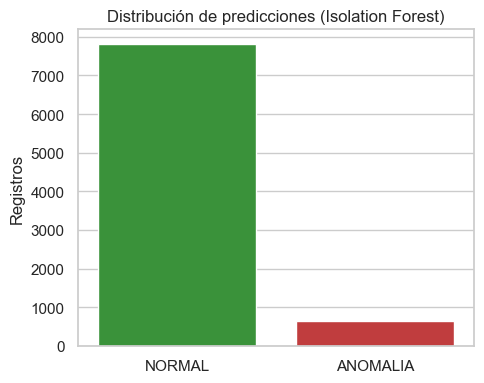

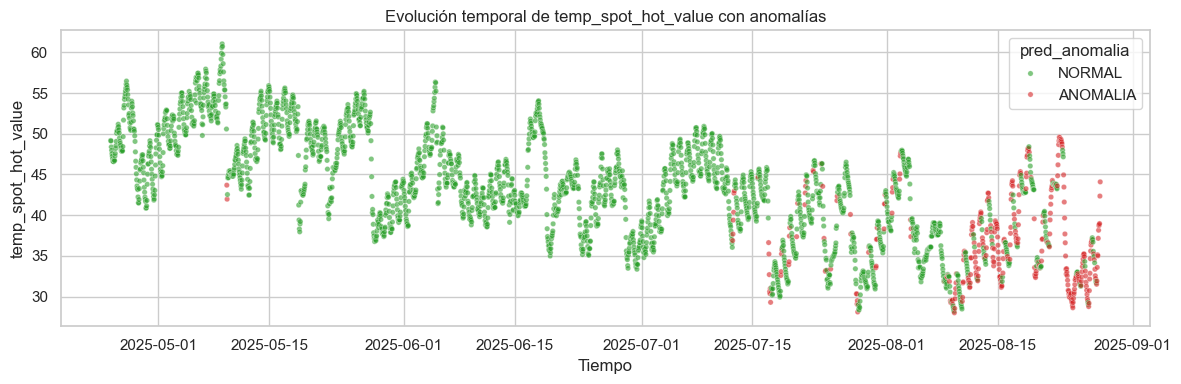

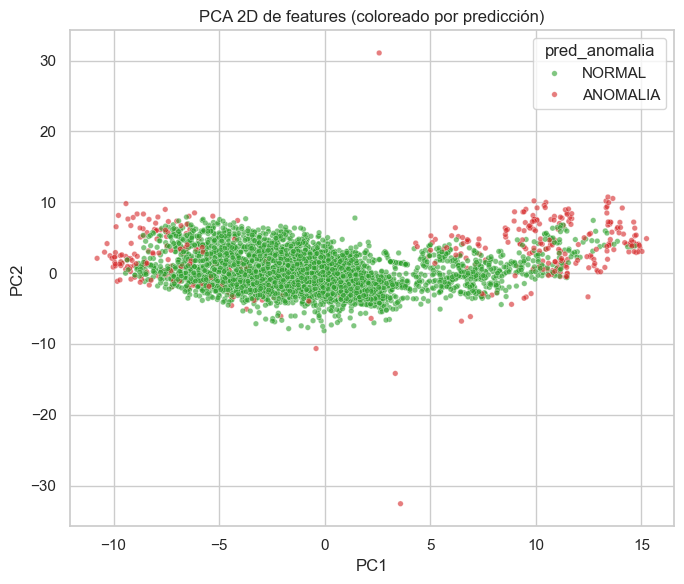

💾 Resultados guardados en: C:\Users\Asus TUF\Desktop\proy_ml\reports\anomaly_detection_results.csv


In [38]:
# -*- coding: utf-8 -*-
# === Imports ===
import pandas as pd
import numpy as np
from pathlib import Path
from deltalake import DeltaTable

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# === 1) Carga desde Delta (tu forma) ===
def find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for cand in (p, *p.parents):
        if (cand / "data").exists():
            return cand
    return p

BASE_DIR = find_repo_root()
RUTA_GOLD_COMPLETE = BASE_DIR / "data" / "capa_gold" / "features_transformador" / "features_complete"

dt = DeltaTable(str(RUTA_GOLD_COMPLETE))
df_gold = dt.to_pandas()
print(f"✅ Gold cargado: {df_gold.shape}")

# === 2) Preparación de variables ===
timestamp_col = None
if "timestamp" in df_gold.columns:
    timestamp_col = "timestamp"
elif isinstance(df_gold.index, pd.DatetimeIndex):
    df_gold = df_gold.reset_index().rename(columns={"index": "timestamp"})
    timestamp_col = "timestamp"

# Etiquetas (si existen)
col_estado_futuro = "estado_futuro" if "estado_futuro" in df_gold.columns else None

# === 3) Construir matriz de features numéricos limpia ===
#   - Eliminar columnas no numéricas y etiquetas explícitas si existen
drop_targets = {"falla_30d", "estado_futuro", "estado_operacional", "rul_dias"}
keep_cols = [c for c in df_gold.columns if c != timestamp_col]
numeric = df_gold[keep_cols].select_dtypes(include=[np.number]).copy()

# Reemplazar inf por NaN
numeric = numeric.replace([np.inf, -np.inf], np.nan)

# Quitar columnas con todo NaN
na_all_cols = [c for c in numeric.columns if numeric[c].isna().all()]
if na_all_cols:
    print(f"ℹ️ Drop columnas all-NaN: {len(na_all_cols)}")
    numeric.drop(columns=na_all_cols, inplace=True)

# Quitar columnas de varianza cero
zero_var_cols = [c for c in numeric.columns if numeric[c].nunique(dropna=True) <= 1]
if zero_var_cols:
    print(f"ℹ️ Drop columnas varianza=0: {len(zero_var_cols)}")
    numeric.drop(columns=zero_var_cols, inplace=True)

# Quitar explícitamente labels numéricos (por si quedaron)
numeric.drop(columns=[c for c in drop_targets if c in numeric.columns], errors="ignore", inplace=True)

print(f"🔧 Features numéricos utilizables: {numeric.shape[1]}")

# === 4) Split lógico para entrenamiento One-Class ===
if col_estado_futuro is not None:
    mask_train = (df_gold[col_estado_futuro] == "NORMAL")
else:
    # Si no hay etiqueta, entrenamos con todo (menos ideal)
    mask_train = pd.Series(True, index=df_gold.index)

X_train_raw = numeric[mask_train].copy()
X_full_raw  = numeric.copy()

# === 5) Imputación + Escalado (fit SOLO con TRAIN) ===
imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()

X_train_imp   = imputer.fit_transform(X_train_raw)
X_train_scaled = scaler.fit_transform(X_train_imp)

# Aplicar las mismas transformaciones al full set
X_full_imp    = imputer.transform(X_full_raw)
X_full_scaled = scaler.transform(X_full_imp)

# === 6) Isolation Forest (entrenado con TRAIN NORMAL) ===
# Ajusta 'contamination' si quieres controlar tasa de anomalía esperada (0.02–0.1 típico)
clf = IsolationForest(
    n_estimators=300,
    contamination=0.05,  # 5% esperado anómalo (ajústalo si te conviene)
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train_scaled)
print("✅ Isolation Forest entrenado")

# === 7) Predicción en todo el set ===
# 1 = inlier (NORMAL), -1 = outlier (ANOMALIA)
pred = clf.predict(X_full_scaled)
df_gold["pred_anomalia"] = np.where(pred == 1, "NORMAL", "ANOMALIA")

# Score crudo (más bajo = más anómalo)
df_gold["anomaly_score"] = -clf.score_samples(X_full_scaled)  # invertido: mayor = más anómalo

print("\n📊 Distribución de predicciones (NORMAL/ANOMALIA):")
print(df_gold["pred_anomalia"].value_counts())

# === 8) Evaluación “proxy” si existe estado_futuro ===
if col_estado_futuro is not None:
    # Colapsamos ALERTA/CRITICO como ANOMALIA (proxy razonable)
    y_true = np.where(df_gold[col_estado_futuro] == "NORMAL", "NORMAL", "ANOMALIA")
    y_pred = df_gold["pred_anomalia"].values

    labels = ["NORMAL", "ANOMALIA"]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labels], columns=[f"pred_{l}" for l in labels])

    print("\n🧪 Matriz de confusión (proxy ALERTA/CRITICO → ANOMALIA):")
    print(cm_df)

# === 9) Visualizaciones ===
# 9.1 Conteo de predicciones
plt.figure(figsize=(5,4))
sns.countplot(x="pred_anomalia", data=df_gold, palette={"NORMAL":"#2ca02c", "ANOMALIA":"#d62728"})
plt.title("Distribución de predicciones (Isolation Forest)")
plt.xlabel("")
plt.ylabel("Registros")
plt.tight_layout()
plt.show()

# 9.2 Evolución temporal (si hay timestamp)
if timestamp_col is not None:
    ts = pd.to_datetime(df_gold[timestamp_col], errors="coerce", utc=True)
    df_plot = df_gold.copy()
    df_plot["_ts"] = ts

    # Elegir una variable para el eje Y (si existe una térmica útil)
    ycol = None
    for cand in ["temp_spot_hot_value", "temp_oil_value", "current_load_value"]:
        if cand in df_plot.columns:
            ycol = cand
            break
    if ycol is None:
        # toma la primera numérica
        ycol = numeric.columns[0]

    plt.figure(figsize=(12,4))
    sel = df_plot[[ "_ts", ycol, "pred_anomalia"]].dropna(subset=[ycol]).sort_values("_ts").tail(3000)  # muestra
    sns.scatterplot(
        data=sel,
        x="_ts", y=ycol,
        hue="pred_anomalia",
        palette={"NORMAL":"#2ca02c", "ANOMALIA":"#d62728"},
        alpha=0.6, s=15
    )
    plt.title(f"Evolución temporal de {ycol} con anomalías")
    plt.xlabel("Tiempo")
    plt.ylabel(ycol)
    plt.tight_layout()
    plt.show()

# 9.3 PCA 2D (ya sin NaN/Inf por la imputación)
try:
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_full_scaled)  # <-- ahora seguro es finito y 2D
    df_gold["pca1"] = X_pca[:,0]
    df_gold["pca2"] = X_pca[:,1]

    plt.figure(figsize=(7,6))
    sns.scatterplot(
        data=df_gold.sample(min(len(df_gold), 5000), random_state=42),
        x="pca1", y="pca2",
        hue="pred_anomalia",
        palette={"NORMAL":"#2ca02c", "ANOMALIA":"#d62728"},
        alpha=0.6, s=16
    )
    plt.title("PCA 2D de features (coloreado por predicción)")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"⚠️ PCA saltado: {e}")

# === 10) Guardar resultados para la demo ===
out_csv = BASE_DIR / "reports" / "anomaly_detection_results.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
df_gold.to_csv(out_csv, index=False)
print(f"💾 Resultados guardados en: {out_csv}")


Epoch 1/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - loss: 0.8347 - val_loss: 2.3670 - learning_rate: 0.0010
Epoch 2/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.5995 - val_loss: 2.2343 - learning_rate: 0.0010
Epoch 3/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.4575 - val_loss: 2.0839 - learning_rate: 0.0010
Epoch 4/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 0.4120 - val_loss: 2.0002 - learning_rate: 0.0010
Epoch 5/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - loss: 0.3641 - val_loss: 2.0374 - learning_rate: 0.0010
Epoch 6/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - loss: 0.3345 - val_loss: 2.1067 - learning_rate: 0.0010
Epoch 7/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - loss: 0.3314 - val_loss: 2.0313 - learning_rate: 0.0010
Epoch 8/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - loss: 0.3316 - val_loss: 2.0939 - learning_rate: 5.0000e-04
Epoch 9/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 134ms/step - loss: 0.3218 - val_loss: 2.0655 - learning_rate: 5.0000e-04
Epoc

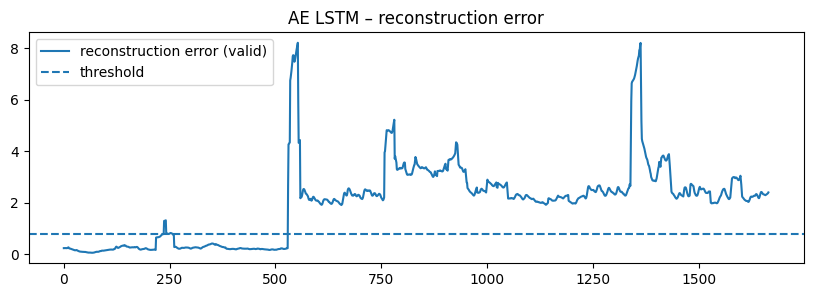

In [37]:
# 1) Carga y preparación (tu misma lógica)
from deltalake import DeltaTable
import numpy as np, pandas as pd, tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import matplotlib.pyplot as plt

def find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for cand in (p, *p.parents):
        if (cand / "data").exists():
            return cand
    return p

BASE_DIR = find_repo_root()
RUTA_GOLD_COMPLETE = BASE_DIR / "data" / "capa_gold" / "features_transformador" / "features_complete"

LEAK_OR_TEXT_COLS = [
    "estado_futuro","falla_30d","rul_dias","severidad_futura",
    "dias_proximo_evento","proximidad_evento","riesgo_acumulativo",
    "estado_operacional","nivel_severidad","variables_anomalas","descripcion_anomalia"
]

dt = DeltaTable(str(RUTA_GOLD_COMPLETE))
df = dt.to_pandas()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df = df.sort_values("timestamp").set_index("timestamp")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X_cols = [c for c in numeric_cols if c not in LEAK_OR_TEXT_COLS]
# Fill seguro
X_df = df[X_cols].replace([np.inf,-np.inf], np.nan)
X_df = X_df.fillna(X_df.median(numeric_only=True))

# 2) Split temporal 80/20 (sin usar labels)
n = len(X_df); cut = int(n*0.80)
X_train_df, X_valid_df = X_df.iloc[:cut], X_df.iloc[cut:]

# 3) Escalado (fit en train)
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train_df), index=X_train_df.index, columns=X_cols)
X_valid_sc = pd.DataFrame(scaler.transform(X_valid_df), index=X_valid_df.index, columns=X_cols)

# 4) Secuencias
LOOKBACK = 24
def make_seqs(X, lookback):
    Xv = X.values; N, F = Xv.shape
    seqs = []
    for t in range(lookback-1, N):
        seqs.append(Xv[t-(lookback-1):t+1])
    return np.array(seqs, dtype=np.float32)

Xtr_seq = make_seqs(X_train_sc, LOOKBACK)
Xva_seq = make_seqs(X_valid_sc, LOOKBACK)

# 5) Autoencoder LSTM
def build_lstm_ae(steps, feats):
    inp = layers.Input(shape=(steps, feats))
    x = layers.Masking()(inp)
    x = layers.LSTM(128, return_sequences=True)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(64, return_sequences=False)(x)
    # bottleneck
    z = layers.Dense(32, activation="relu")(x)
    # decoder
    x = layers.RepeatVector(steps)(z)
    x = layers.LSTM(64, return_sequences=True)(x)
    x = layers.LSTM(128, return_sequences=True)(x)
    out = layers.TimeDistributed(layers.Dense(feats))(x)
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return model

ae = build_lstm_ae(LOOKBACK, len(X_cols))
es = callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)

hist = ae.fit(
    Xtr_seq, Xtr_seq,
    validation_data=(Xva_seq, Xva_seq),
    epochs=60, batch_size=128,
    callbacks=[es, rlr], verbose=1
)

# 6) Puntaje de anomalía = error de reconstrucción (MSE por secuencia)
def recon_error(model, Xseq):
    rec = model.predict(Xseq, verbose=0)
    err = np.mean((Xseq - rec)**2, axis=(1,2))
    return err

err_tr = recon_error(ae, Xtr_seq)
err_va = recon_error(ae, Xva_seq)

# 7) Umbral (p.ej. percentil 95 del train) → anómalo si error > thr
thr = np.quantile(err_tr, 0.95)
anomaly_flag_valid = (err_va > thr).astype(int)

print("Umbral de anomalía:", thr)
print("Tasa de anomalías en valid:", anomaly_flag_valid.mean())

# (Opcional) graficar serie de error y umbral
plt.figure(figsize=(10,3))
plt.plot(err_va, label="reconstruction error (valid)")
plt.axhline(thr, linestyle="--", label="threshold")
plt.legend(); plt.title("AE LSTM – reconstruction error"); plt.show()


Drop constantes: ['suboptimal_operation']
Clases: {'ALERTA': 0, 'CRITICO': 1, 'NORMAL': 2}

== SPLIT ==
Train: (6754, 58)  Valid: (1689, 58)
Train range: 2024-09-10 04:00:00+00:00 → 2025-06-18 13:00:00+00:00
Valid range: 2025-06-18 14:00:00+00:00 → 2025-08-27 22:00:00+00:00
Distribución VALID (bin): Counter({np.int64(0): 1329, np.int64(1): 360})

== SEQ ==
Xtr_seq: (6728, 24, 58) | Xva_seq: (1663, 24, 58)
y_valid_bin aligned: (1663,)
Epoch 1/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - loss: 0.8311 - val_loss: 2.6055 - learning_rate: 0.0010
Epoch 2/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 0.5924 - val_loss: 2.3722 - learning_rate: 0.0010
Epoch 3/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 0.4929 - val_loss: 2.3456 - learning_rate: 0.0010
Epoch 4/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 131ms/step - loss: 0.4078 - val_loss: 2.2923 - learning_rate: 0.0010
Epoch 5/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - loss: 0.3700 - val_loss: 2.2615 - learning_rate: 0.0010
Epoch 6/60
53/

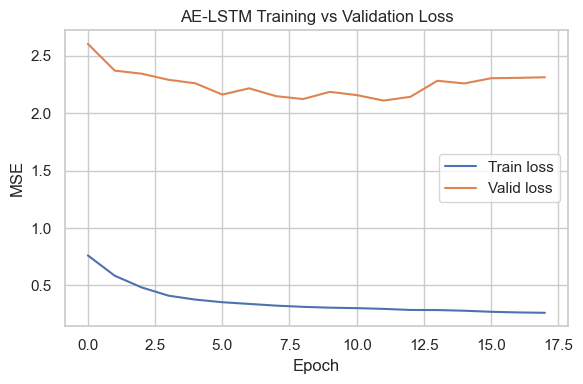


[AE-LSTM] ROC-AUC=0.758 | PR-AUC=0.387 | thr_p95=0.616433 | best F1=0.523 @ thr=2.458318


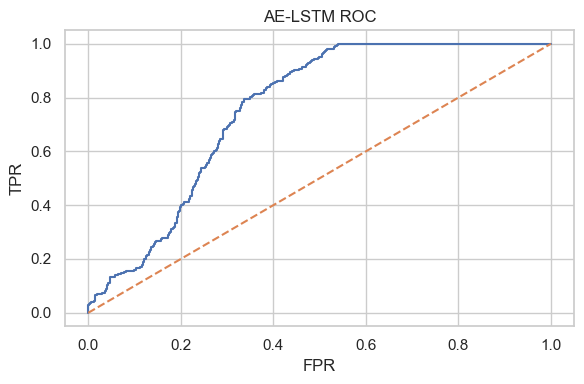

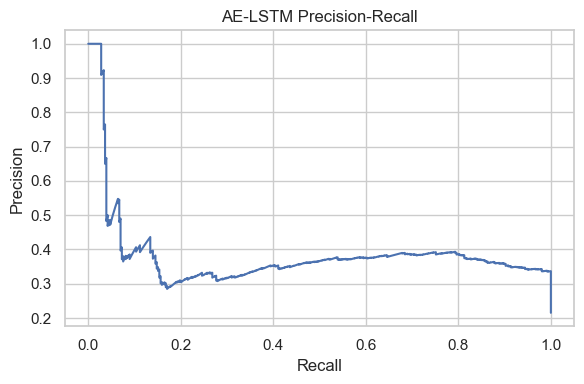


AE-LSTM @thr p95 (unsupervised) (thr=0.616433)
              precision    recall  f1-score   support

      NORMAL     1.0000    0.3739    0.5443      1305
   NO-NORMAL     0.3047    1.0000    0.4671       358

    accuracy                         0.5087      1663
   macro avg     0.6523    0.6870    0.5057      1663
weighted avg     0.8503    0.5087    0.5277      1663



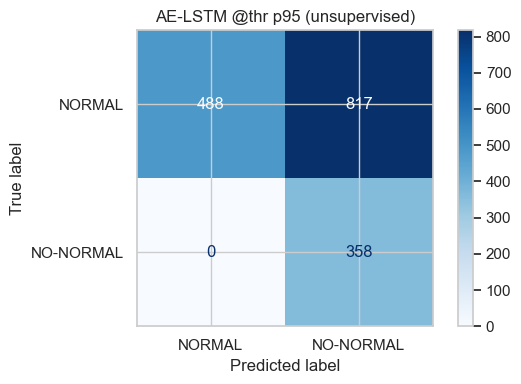


AE-LSTM @thr óptimo F1 (valid-supervised) (thr=2.458318)
              precision    recall  f1-score   support

      NORMAL     0.9186    0.6659    0.7721      1305
   NO-NORMAL     0.3919    0.7849    0.5228       358

    accuracy                         0.6915      1663
   macro avg     0.6553    0.7254    0.6474      1663
weighted avg     0.8052    0.6915    0.7184      1663



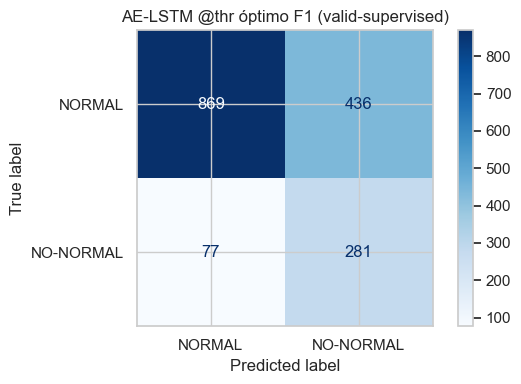


[IForest] ROC-AUC=0.715 | PR-AUC=0.341


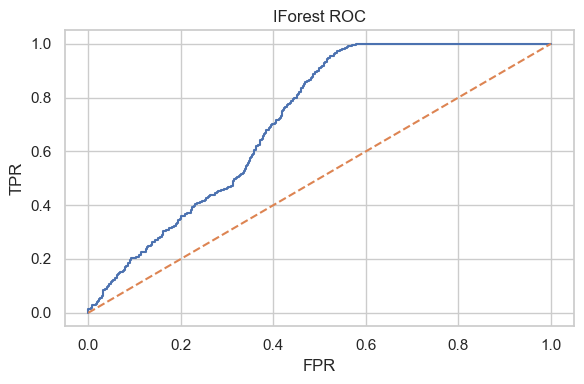

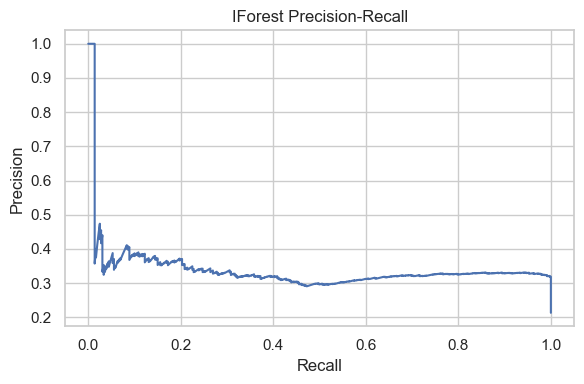


IForest @thr p95 (unsupervised) (thr=0.507428)
              precision    recall  f1-score   support

      NORMAL     0.9965    0.4296    0.6004      1329
   NO-NORMAL     0.3208    0.9944    0.4851       360

    accuracy                         0.5500      1689
   macro avg     0.6586    0.7120    0.5428      1689
weighted avg     0.8525    0.5500    0.5758      1689



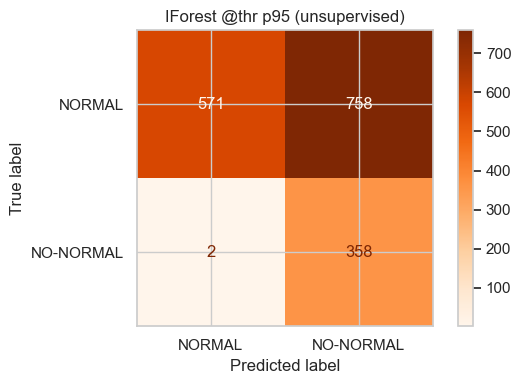


IForest @thr óptimo F1 (valid-supervised) (thr=0.515595)
              precision    recall  f1-score   support

      NORMAL     0.9854    0.4567    0.6242      1329
   NO-NORMAL     0.3271    0.9750    0.4899       360

    accuracy                         0.5672      1689
   macro avg     0.6563    0.7159    0.5570      1689
weighted avg     0.8451    0.5672    0.5955      1689



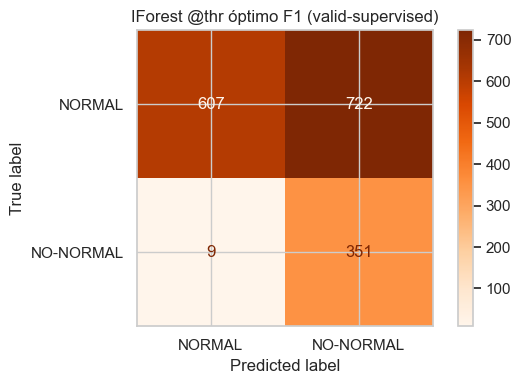


✅ Artefactos guardados en: C:\Users\Asus TUF\Desktop\proy_ml\data\capa_gold\artifacts_anomalia


In [ ]:
# ============================================
# 0) Imports y setup
# ============================================
import os
from pathlib import Path
from typing import List
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from deltalake import DeltaTable
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve,
    f1_score
)
from sklearn.ensemble import IsolationForest

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (6, 4)

# Config ventanas
LOOKBACK = 24         # pasos históricos por secuencia (p.ej., 24 horas)
HORIZON_SHIFT = 3     # 0 = reconstruir/puntuar en t; (si quisieras +1, cambia a 1)

# Paths
def find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for cand in (p, *p.parents):
        if (cand / "data").exists(): return cand
    return p

BASE_DIR = find_repo_root()
RUTA_GOLD_COMPLETE = BASE_DIR / "data" / "capa_gold" / "features_transformador" / "features_complete"
ARTIFACTS_DIR = BASE_DIR / "data" / "capa_gold" / "artifacts_anomalia"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# Columnas a excluir (fuga/texto/derivadas del futuro)
LEAK_OR_TEXT_COLS: List[str] = [
    "estado_futuro","falla_30d","rul_dias","severidad_futura",
    "dias_proximo_evento","proximidad_evento","riesgo_acumulativo",
    "estado_operacional","nivel_severidad","variables_anomalas","descripcion_anomalia"
]

# ============================================
# 1) Carga Gold y prep básica
# ============================================
dt = DeltaTable(str(RUTA_GOLD_COMPLETE))
df = dt.to_pandas()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df = df.sort_values("timestamp").set_index("timestamp")

TARGET = "estado_futuro"
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X_cols = [c for c in numeric_cols if c not in LEAK_OR_TEXT_COLS]

# quitar constantes y >30% NaN
const_cols = [c for c in X_cols if df[c].nunique() <= 1]
if const_cols:
    print("Drop constantes:", const_cols)
    X_cols = [c for c in X_cols if c not in const_cols]

nan_ratio = df[X_cols].isna().mean()
high_nan = nan_ratio[nan_ratio > 0.30].index.tolist()
if high_nan:
    print("Drop >30% NaN:", high_nan)
    X_cols = [c for c in X_cols if c not in high_nan]

# X, y y saneo básico (sin fuga)
X_df = df[X_cols].replace([np.inf,-np.inf], np.nan)
X_df = X_df.fillna(X_df.median(numeric_only=True))
y_raw = df[TARGET].astype(str)

# label encoder para poder construir binario en valid
le = LabelEncoder()
y_enc = le.fit_transform(y_raw)
print("Clases:", dict(zip(le.classes_, range(len(le.classes_)))))

# ============================================
# 2) Split temporal 80/20 (solo por filas)
# ============================================
n = len(X_df); cut = int(n*0.80)
X_train_df, X_valid_df = X_df.iloc[:cut], X_df.iloc[cut:]
y_train_vec, y_valid_vec = y_enc[:cut], y_enc[cut:]

print("\n== SPLIT ==")
print("Train:", X_train_df.shape, " Valid:", X_valid_df.shape)
print("Train range:", X_train_df.index.min(), "→", X_train_df.index.max())
print("Valid range:", X_valid_df.index.min(), "→", X_valid_df.index.max())

# binario para evaluación (solo en VALID): NORMAL vs NO-NORMAL
try:
    normal_id = int(np.where(le.classes_ == "NORMAL")[0][0])
except Exception:
    # si no existe etiqueta "NORMAL", tomamos la clase mayoritaria del train como normal
    normal_id = Counter(y_train_vec).most_common(1)[0][0]

y_valid_bin = (y_valid_vec != normal_id).astype(int)  # 1 = NO-NORMAL (positivo), 0 = NORMAL

print("Distribución VALID (bin):", Counter(y_valid_bin))

# ============================================
# 3) Escalado (fit en train) y construcción de secuencias
# ============================================
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train_df), index=X_train_df.index, columns=X_cols)
X_valid_sc = pd.DataFrame(scaler.transform(X_valid_df), index=X_valid_df.index, columns=X_cols)

def make_sequences(X: pd.DataFrame, lookback: int):
    Xv = X.values; N, F = Xv.shape
    seqs = []
    for t in range(lookback-1, N-HORIZON_SHIFT):
        seqs.append(Xv[t-(lookback-1):t+1])
    return np.array(seqs, dtype=np.float32)

Xtr_seq = make_sequences(X_train_sc, LOOKBACK)
Xva_seq = make_sequences(X_valid_sc, LOOKBACK)

# alineamos y_valid_bin al número de secuencias de valid
yva_bin_aligned = y_valid_bin[LOOKBACK-1:len(y_valid_bin)-HORIZON_SHIFT]

print("\n== SEQ ==")
print("Xtr_seq:", Xtr_seq.shape, "| Xva_seq:", Xva_seq.shape)
print("y_valid_bin aligned:", yva_bin_aligned.shape)

# ============================================
# 4) Autoencoder LSTM (entrena SOLO con train)
# ============================================
def build_lstm_ae(steps, feats):
    inp = layers.Input(shape=(steps, feats))
    x = layers.Masking()(inp)
    x = layers.LSTM(128, return_sequences=True)(x)
    x = layers.Dropout(0.2)(x) # evitar overfitting
    x = layers.LSTM(64)(x) #sir
    z = layers.Dense(32, activation="relu")(x)
    x = layers.RepeatVector(steps)(z)
    x = layers.LSTM(64, return_sequences=True)(x)
    x = layers.LSTM(128, return_sequences=True)(x)
    out = layers.TimeDistributed(layers.Dense(feats))(x)
    m = models.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return m

ae = build_lstm_ae(LOOKBACK, len(X_cols))
es = callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)

hist = ae.fit(
    Xtr_seq, Xtr_seq,
    validation_data=(Xva_seq, Xva_seq),
    epochs=80, batch_size=128,
    callbacks=[es, rlr], verbose=1
)

# Curva de entrenamiento vs validación (para detectar over/underfitting)
plt.plot(hist.history["loss"], label="Train loss")
plt.plot(hist.history["val_loss"], label="Valid loss")
plt.title("AE-LSTM Training vs Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend(); plt.tight_layout(); plt.show()

# Puntaje de anomalía = error de reconstrucción (más alto = más anómalo)
def recon_error(model, Xseq):
    rec = model.predict(Xseq, verbose=0)
    return np.mean((Xseq - rec)**2, axis=(1,2))

err_tr = recon_error(ae, Xtr_seq)
err_va = recon_error(ae, Xva_seq)

# Umbral 1: percentil 95 del train (no usa etiquetas)
thr_p95 = float(np.quantile(err_tr, 0.95))
# Umbral 2: óptimo en VALID para maximizar F1 (sí usa y_valid_bin)
def best_thr_f1(scores, y_true, grid=200):
    lo, hi = scores.min(), scores.max()
    ths = np.linspace(lo, hi, grid)
    best = (0, None)
    for th in ths:
        yhat = (scores >= th).astype(int)  # >=th => NORMAL (0), pero queremos 1 = NO-NORMAL
        yhat_anom = (scores > th).astype(int)  # 1 = anómalo
        f1 = f1_score(y_true, yhat_anom, zero_division=0)
        if f1 > best[0]: best = (f1, th)
    return best

f1_opt, thr_opt = best_thr_f1(err_va, yva_bin_aligned)

# Métricas sin umbral (umbral-libre): ROC-AUC y PR-AUC
ae_roc_auc = roc_auc_score(yva_bin_aligned, err_va)
ae_pr_auc  = average_precision_score(yva_bin_aligned, err_va)  # baseline ≈ prevalencia de NO-NORMAL

print(f"\n[AE-LSTM] ROC-AUC={ae_roc_auc:.3f} | PR-AUC={ae_pr_auc:.3f} | thr_p95={thr_p95:.6f} | best F1={f1_opt:.3f} @ thr={thr_opt:.6f}")

# Curvas ROC y PR
fpr, tpr, _ = roc_curve(yva_bin_aligned, err_va)
prec, rec, _ = precision_recall_curve(yva_bin_aligned, err_va)
plt.plot(fpr, tpr); plt.plot([0,1],[0,1],'--'); plt.title("AE-LSTM ROC"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.tight_layout(); plt.show()
plt.plot(rec, prec); plt.title("AE-LSTM Precision-Recall"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.tight_layout(); plt.show()

# Evaluación con thr_p95 y thr_opt
def eval_with_thr(scores, y_true, thr, title):
    yhat = (scores > thr).astype(int)  # 1 = anómalo
    print(f"\n{title} (thr={thr:.6f})")
    print(classification_report(y_true, yhat, target_names=["NORMAL","NO-NORMAL"], digits=4, zero_division=0))
    cm = confusion_matrix(y_true, yhat, labels=[0,1])
    ConfusionMatrixDisplay(cm, display_labels=["NORMAL","NO-NORMAL"]).plot(cmap="Blues")
    plt.title(title); plt.tight_layout(); plt.show()

eval_with_thr(err_va, yva_bin_aligned, thr_p95, "AE-LSTM @thr p95 (unsupervised)")
eval_with_thr(err_va, yva_bin_aligned, thr_opt, "AE-LSTM @thr óptimo F1 (valid-supervised)")

# ============================================
# 5) Isolation Forest (entrena SOLO con train, sin etiquetas)
# ============================================
scaler_if = StandardScaler()
Xtr_if = scaler_if.fit_transform(X_train_df)
Xva_if = scaler_if.transform(X_valid_df)

iforest = IsolationForest(
    n_estimators=400, contamination=0.10, random_state=RANDOM_STATE, n_jobs=-1
).fit(Xtr_if)

scores_if = -iforest.score_samples(Xva_if)  # más alto = más anómalo
# Métricas umbral-libre
if_roc_auc = roc_auc_score(y_valid_bin, scores_if)
if_pr_auc  = average_precision_score(y_valid_bin, scores_if)
print(f"\n[IForest] ROC-AUC={if_roc_auc:.3f} | PR-AUC={if_pr_auc:.3f}")

# Umbrales: p95 de score en TRAIN (estimado via Xtr_if) y óptimo por F1
scores_if_tr = -iforest.score_samples(Xtr_if)
thr_if_p95 = float(np.quantile(scores_if_tr, 0.95))

f1_if_opt, thr_if_opt = best_thr_f1(scores_if, y_valid_bin)

# Curvas ROC/PR
fpr, tpr, _ = roc_curve(y_valid_bin, scores_if)
prec, rec, _ = precision_recall_curve(y_valid_bin, scores_if)
plt.plot(fpr, tpr); plt.plot([0,1],[0,1],'--'); plt.title("IForest ROC"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.tight_layout(); plt.show()
plt.plot(rec, prec); plt.title("IForest Precision-Recall"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.tight_layout(); plt.show()

# Evaluación con thr_p95 y thr_opt
def eval_if_thr(scores, y_true, thr, title):
    yhat = (scores > thr).astype(int)  # 1 = anómalo
    print(f"\n{title} (thr={thr:.6f})")
    print(classification_report(y_true, yhat, target_names=["NORMAL","NO-NORMAL"], digits=4, zero_division=0))
    cm = confusion_matrix(y_true, yhat, labels=[0,1])
    ConfusionMatrixDisplay(cm, display_labels=["NORMAL","NO-NORMAL"]).plot(cmap="Oranges")
    plt.title(title); plt.tight_layout(); plt.show()

eval_if_thr(scores_if, y_valid_bin, thr_if_p95, "IForest @thr p95 (unsupervised)")
eval_if_thr(scores_if, y_valid_bin, thr_if_opt, "IForest @thr óptimo F1 (valid-supervised)")

# ============================================
# 6) Guardado de artefactos (modelo, scaler, columnas y umbrales)
# ============================================
ae.save(ARTIFACTS_DIR / "ae_lstm.keras")
pd.Series(X_cols).to_csv(ARTIFACTS_DIR / "feature_columns.csv", index=False)
import joblib, json
joblib.dump(scaler, ARTIFACTS_DIR / "scaler_ae.pkl")
joblib.dump(scaler_if, ARTIFACTS_DIR / "scaler_if.pkl")
joblib.dump(iforest, ARTIFACTS_DIR / "iforest.pkl")

meta = {
    "lookback": LOOKBACK, "horizon_shift": HORIZON_SHIFT,
    "classes": le.classes_.tolist(),
    "normal_id": int(normal_id),
    "ae_thr_p95": float(thr_p95),
    "ae_thr_opt_valid": float(thr_opt),
    "if_thr_p95": float(thr_if_p95),
    "if_thr_opt_valid": float(thr_if_opt),
}
with open(ARTIFACTS_DIR / "meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\n✅ Artefactos guardados en:", ARTIFACTS_DIR)


Drop constantes: ['suboptimal_operation']
Clases: {'ALERTA': 0, 'CRITICO': 1, 'NORMAL': 2}

== SPLIT ==
Train: (6754, 58)  Valid: (1689, 58)
Train range: 2024-09-10 04:00:00+00:00 → 2025-06-18 13:00:00+00:00
Valid range: 2025-06-18 14:00:00+00:00 → 2025-08-27 22:00:00+00:00
Distribución VALID (bin): Counter({np.int64(0): 1329, np.int64(1): 360})

== SEQ ==
Xtr_seq: (6731, 24, 58) | Xva_seq: (1666, 24, 58)
y_valid_bin aligned: (1666,)
Epoch 1/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - loss: 0.8571 - val_loss: 2.4584 - learning_rate: 0.0010
Epoch 2/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.5838 - val_loss: 2.4098 - learning_rate: 0.0010
Epoch 3/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.4696 - val_loss: 2.3227 - learning_rate: 0.0010
Epoch 4/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 0.4102 - val_loss: 2.2603 - learning_rate: 0.0010
Epoch 5/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 0.3782 - val_loss: 2.0715 - learning_rate: 0.0010
Epoch 6/60
53/5

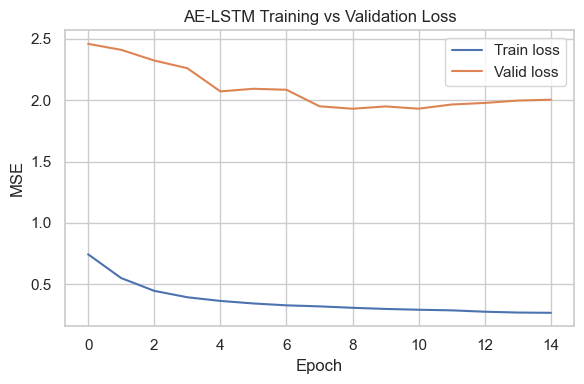


[AE-LSTM] ROC-AUC=0.752 | PR-AUC=0.374


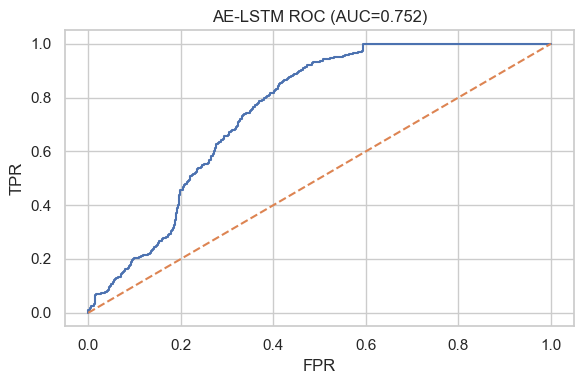

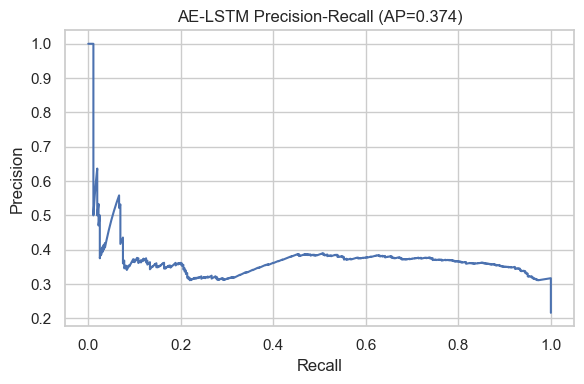

[AE] best F2=0.699 @ thr=1.391247 | P=0.317 R=1.000 (F1=0.481)

AE-LSTM @thr p95 (unsupervised) (thr=0.635847)
              precision    recall  f1-score   support

      NORMAL     1.0000    0.3744    0.5448      1306
   NO-NORMAL     0.3059    1.0000    0.4684       360

    accuracy                         0.5096      1666
   macro avg     0.6529    0.6872    0.5066      1666
weighted avg     0.8500    0.5096    0.5283      1666



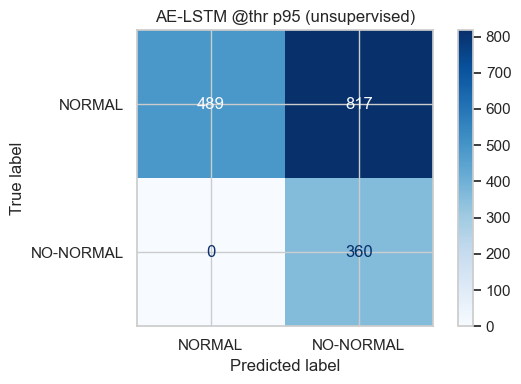


AE-LSTM @thr F2 (valid-supervised) (thr=1.391247)
              precision    recall  f1-score   support

      NORMAL     1.0000    0.4058    0.5773      1306
   NO-NORMAL     0.3169    1.0000    0.4813       360

    accuracy                         0.5342      1666
   macro avg     0.6585    0.7029    0.5293      1666
weighted avg     0.8524    0.5342    0.5566      1666



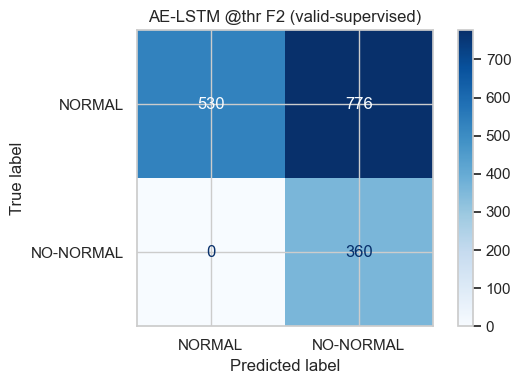


[IForest] ROC-AUC=0.715 | PR-AUC=0.341


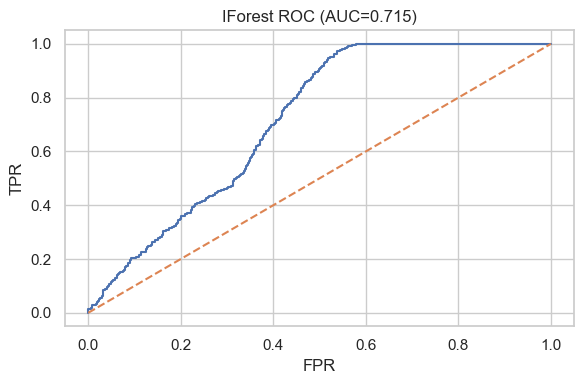

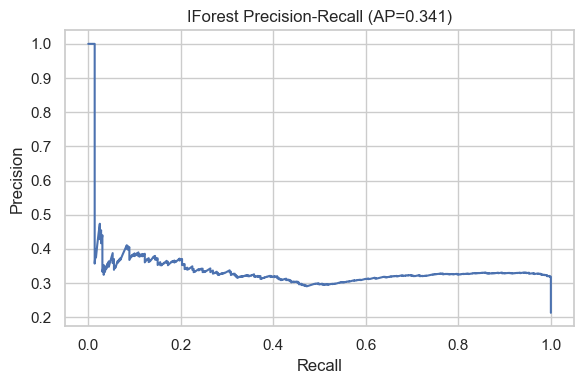

[IF] best F2=0.702 @ thr=0.509752 | P=0.323 R=0.992 (F1=0.488)

IForest @thr p95 (unsupervised) (thr=0.507428)
              precision    recall  f1-score   support

      NORMAL     0.9965    0.4296    0.6004      1329
   NO-NORMAL     0.3208    0.9944    0.4851       360

    accuracy                         0.5500      1689
   macro avg     0.6586    0.7120    0.5428      1689
weighted avg     0.8525    0.5500    0.5758      1689



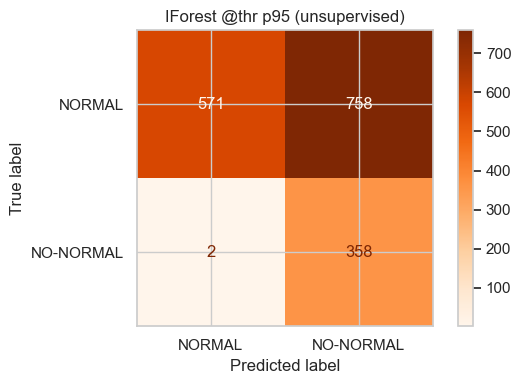


IForest @thr F2 (valid-supervised) (thr=0.509752)
              precision    recall  f1-score   support

      NORMAL     0.9949    0.4379    0.6082      1329
   NO-NORMAL     0.3234    0.9917    0.4877       360

    accuracy                         0.5560      1689
   macro avg     0.6591    0.7148    0.5479      1689
weighted avg     0.8517    0.5560    0.5825      1689



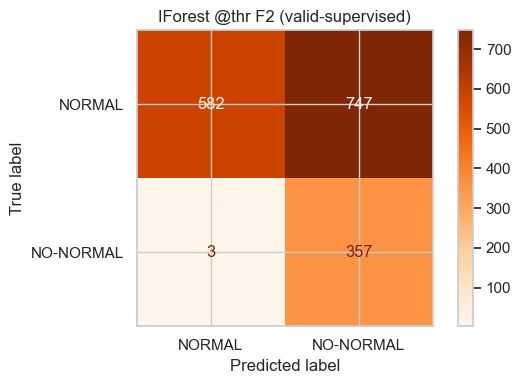


[ENSEMBLE] best F2=0.701 @ thr=0.276104 | P=0.320 R=1.000 (F1=0.485)

ENSEMBLE @thr F2 (thr=0.276104)
              precision    recall  f1-score   support

      NORMAL     1.0000    0.4135    0.5850      1306
   NO-NORMAL     0.3197    1.0000    0.4845       360

    accuracy                         0.5402      1666
   macro avg     0.6599    0.7067    0.5348      1666
weighted avg     0.8530    0.5402    0.5633      1666



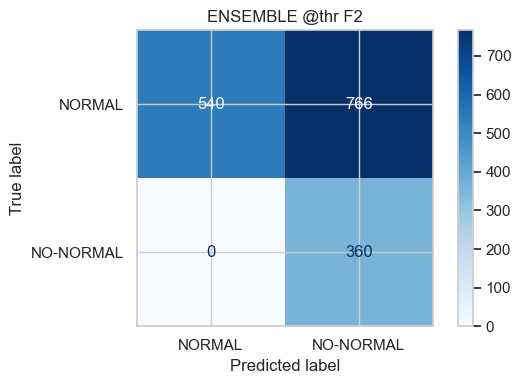


[Ensamble + smoothing 3/5]
              precision    recall  f1-score   support

      NORMAL     1.0000    0.4112    0.5827      1306
   NO-NORMAL     0.3189    1.0000    0.4835       360

    accuracy                         0.5384      1666
   macro avg     0.6594    0.7056    0.5331      1666
weighted avg     0.8528    0.5384    0.5613      1666



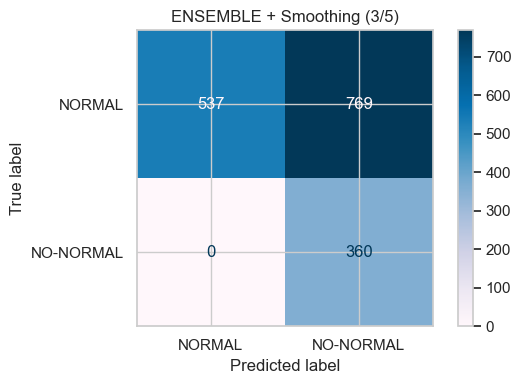


[AE] Top features que explican anomalías (promedio):
power_factor_estimated            74.026749
thermal_efficiency                17.290560
current_load_value_transient       7.737730
overload_indicator                 5.569985
year                               3.832050
power_apparent_value_transient     3.349193
power_apparent_value_stability     2.249233
current_load_value_stability       2.171103
voltage_value_transient            1.833010
load_factor_power                  1.782637
dtype: float32


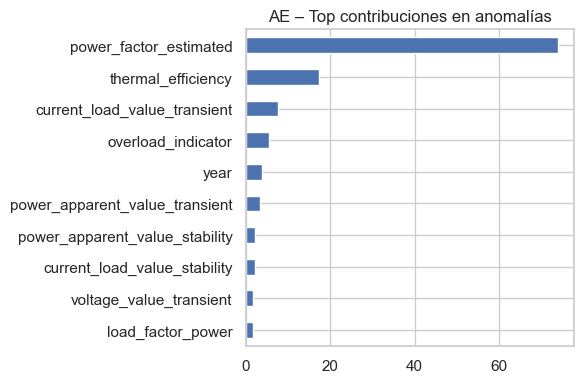

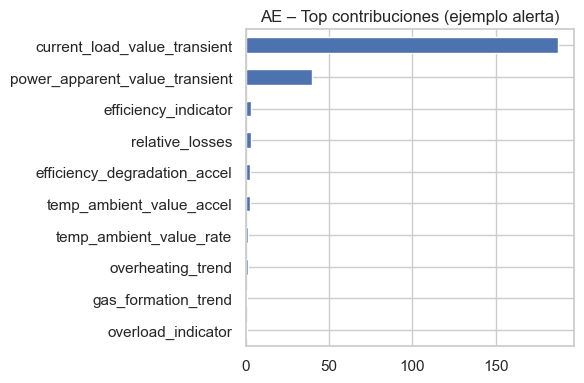


[Surrogate Tree] Top features que separan NORMAL/ANÓMALO (ensamble+smoothing):
load_factor_power          0.983378
voltage_value_stability    0.007521
voltage_value              0.004736
temp_rise_hot              0.003506
overheating_trend          0.000860
temp_oil_oltc_value        0.000000
current_load_value         0.000000
temp_ambient_value         0.000000
temp_bubbling_value        0.000000
temp_spot_hot_value        0.000000
year                       0.000000
month                      0.000000
dtype: float64


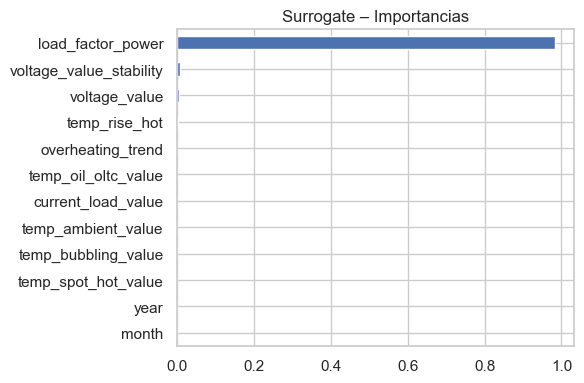


✅ Artefactos guardados en: C:\Users\Asus TUF\Desktop\proy_ml\data\capa_gold\artifacts_anomalia


In [ ]:
# ============================================
# 0) Imports, config y utilidades
# ============================================
import os, json
from pathlib import Path
from typing import List, Tuple
from collections import Counter, deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from deltalake import DeltaTable
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve,
    f1_score
)
from sklearn.ensemble import IsolationForest
from sklearn.tree import DecisionTreeClassifier

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import joblib

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (6, 4)

# Config ventanas
LOOKBACK = 24         # pasos por secuencia (p.ej., 24 horas)
HORIZON_SHIFT = 0     # 0 = puntuar t; si quisieras +1, cambia a 1

# Paths
def find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for cand in (p, *p.parents):
        if (cand / "data").exists(): return cand
    return p

BASE_DIR = find_repo_root()
RUTA_GOLD_COMPLETE = BASE_DIR / "data" / "capa_gold" / "features_transformador" / "features_complete"

# Carpeta de artefactos 
ARTIFACTS_DIR = BASE_DIR / "data" / "capa_gold" / "artifacts_anomalia"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# Columnas a excluir (fuga/texto/derivadas del futuro)
LEAK_OR_TEXT_COLS: List[str] = [
    "estado_futuro","falla_30d","rul_dias","severidad_futura",
    "dias_proximo_evento","proximidad_evento","riesgo_acumulativo",
    "estado_operacional","nivel_severidad","variables_anomalas","descripcion_anomalia"
]

TARGET = "estado_futuro"
# --------------------------------------------
# Utils métricas y gráficos
# --------------------------------------------
def plot_roc_pr(y_true: np.ndarray, scores: np.ndarray, title_prefix: str):
    fpr, tpr, _ = roc_curve(y_true, scores)
    prec, rec, _ = precision_recall_curve(y_true, scores)
    roc_auc = roc_auc_score(y_true, scores)
    pr_auc  = average_precision_score(y_true, scores)

    plt.plot(fpr, tpr); plt.plot([0,1],[0,1],'--')
    plt.title(f"{title_prefix} ROC (AUC={roc_auc:.3f})")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.tight_layout(); plt.show()

    plt.plot(rec, prec)
    plt.title(f"{title_prefix} Precision-Recall (AP={pr_auc:.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.tight_layout(); plt.show()

def eval_with_thr(scores: np.ndarray, y_true: np.ndarray, thr: float, title: str, cmap="Blues"):
    yhat = (scores > thr).astype(int)  # 1 = anómalo
    print(f"\n{title} (thr={thr:.6f})")
    print(classification_report(y_true, yhat, target_names=["NORMAL","NO-NORMAL"], digits=4, zero_division=0))
    cm = confusion_matrix(y_true, yhat, labels=[0,1])
    ConfusionMatrixDisplay(cm, display_labels=["NORMAL","NO-NORMAL"]).plot(cmap=cmap)
    plt.title(title); plt.tight_layout(); plt.show()
    return yhat

def best_thr_fbeta(scores: np.ndarray, y_true: np.ndarray, beta: float = 2.0, grid: int = 400):
    """
    Maximiza F_beta para clase positiva = NO-NORMAL.
    scores: mayor ⇒ más anómalo.
    """
    lo, hi = scores.min(), scores.max()
    ths = np.linspace(lo, hi, grid)
    best = (0.0, None, (0,0,0))  # (fbeta, thr, (precision, recall, f1))
    b2 = beta * beta
    for th in ths:
        yhat = (scores > th).astype(int)
        tp = ((y_true==1) & (yhat==1)).sum()
        fp = ((y_true==0) & (yhat==1)).sum()
        fn = ((y_true==1) & (yhat==0)).sum()
        prec = tp / (tp + fp) if (tp+fp)>0 else 0.0
        rec  = tp / (tp + fn) if (tp+fn)>0 else 0.0
        denom = b2*prec + rec
        fbeta = ((1+b2)*prec*rec/denom) if denom>0 else 0.0
        if fbeta > best[0]:
            f1 = (2*prec*rec)/(prec+rec) if (prec+rec)>0 else 0.0
            best = (fbeta, th, (prec, rec, f1))
    return best

def smooth_alerts(binary_seq: np.ndarray, k: int = 3, m: int = 5) -> np.ndarray:
    """
    Devuelve 1 si en la ventana móvil de tamaño m hay al menos k anomalías.
    """
    out = np.zeros_like(binary_seq)
    win = deque(maxlen=m)
    count = 0
    for i, v in enumerate(binary_seq):
        if len(win) == m:
            count -= win[0]
        win.append(v)
        count += v
        out[i] = 1 if count >= k else 0
    return out

def minmax_transform(x: np.ndarray, lo: float, hi: float):
    eps = 1e-12
    return (x - lo) / max(hi - lo, eps)

# ============================================
# 1) Carga Gold y prep básica
# ============================================
dt = DeltaTable(str(RUTA_GOLD_COMPLETE))
df = dt.to_pandas()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df = df.sort_values("timestamp").set_index("timestamp")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X_cols = [c for c in numeric_cols if c not in LEAK_OR_TEXT_COLS]

# quitar constantes y >30% NaN
const_cols = [c for c in X_cols if df[c].nunique() <= 1]
if const_cols:
    print("Drop constantes:", const_cols)
    X_cols = [c for c in X_cols if c not in const_cols]

nan_ratio = df[X_cols].isna().mean()
high_nan = nan_ratio[nan_ratio > 0.30].index.tolist()
if high_nan:
    print("Drop >30% NaN:", high_nan)
    X_cols = [c for c in X_cols if c not in high_nan]

# X, y y saneo básico
X_df = df[X_cols].replace([np.inf,-np.inf], np.nan)
X_df = X_df.fillna(X_df.median(numeric_only=True))
y_raw = df[TARGET].astype(str)

# label encoder (para evaluar binario en valid)
le = LabelEncoder()
y_enc = le.fit_transform(y_raw)
print("Clases:", dict(zip(le.classes_, range(len(le.classes_)))))

# ============================================
# 2) Split temporal
# ============================================
n = len(X_df); cut = int(n*0.80)
X_train_df, X_valid_df = X_df.iloc[:cut], X_df.iloc[cut:]
y_train_vec, y_valid_vec = y_enc[:cut], y_enc[cut:]

print("\n== SPLIT ==")
print("Train:", X_train_df.shape, " Valid:", X_valid_df.shape)
print("Train range:", X_train_df.index.min(), "→", X_train_df.index.max())
print("Valid range:", X_valid_df.index.min(), "→", X_valid_df.index.max())

# binario para evaluación (solo en VALID): 1 = NO-NORMAL
try:
    normal_id = int(np.where(le.classes_ == "NORMAL")[0][0])
except Exception:
    normal_id = Counter(y_train_vec).most_common(1)[0][0]

y_valid_bin = (y_valid_vec != normal_id).astype(int)
print("Distribución VALID (bin):", Counter(y_valid_bin))

# ---- Opción B: ventana móvil (descomenta si quieres usar esta estrategia) ----
# WINDOW_DAYS = 180
# end_valid = X_df.index.max()
# start_train = end_valid - pd.Timedelta(days=WINDOW_DAYS + 30)
# split_date  = end_valid - pd.Timedelta(days=30)
# X_train_df = X_df.loc[(X_df.index >= start_train) & (X_df.index < split_date)]
# X_valid_df = X_df.loc[X_df.index >= split_date]
# y_train_vec = y_enc[(df.index >= start_train) & (df.index < split_date)]
# y_valid_vec = y_enc[(df.index >= split_date)]
# y_valid_bin = (y_valid_vec != normal_id).astype(int)
# print("\n== SPLIT (ventana móvil) ==")
# print("Train:", X_train_df.shape, " Valid:", X_valid_df.shape)

# ============================================
# 3) Escalado (fit en train) y construcción de secuencias
# ============================================
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train_df), index=X_train_df.index, columns=X_cols)
X_valid_sc = pd.DataFrame(scaler.transform(X_valid_df), index=X_valid_df.index, columns=X_cols)

def make_sequences(X: pd.DataFrame, lookback: int):
    Xv = X.values; N, F = Xv.shape
    seqs = []
    for t in range(lookback-1, N-HORIZON_SHIFT):
        seqs.append(Xv[t-(lookback-1):t+1])
    return np.array(seqs, dtype=np.float32)

Xtr_seq = make_sequences(X_train_sc, LOOKBACK)
Xva_seq = make_sequences(X_valid_sc, LOOKBACK)
yva_bin_aligned = y_valid_bin[LOOKBACK-1:len(y_valid_bin)-HORIZON_SHIFT]

print("\n== SEQ ==")
print("Xtr_seq:", Xtr_seq.shape, "| Xva_seq:", Xva_seq.shape)
print("y_valid_bin aligned:", yva_bin_aligned.shape)

# ============================================
# 4) Autoencoder LSTM
# ============================================
def build_lstm_ae(steps, feats):
    inp = layers.Input(shape=(steps, feats))
    x = layers.Masking()(inp)
    x = layers.LSTM(128, return_sequences=True)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(64)(x)
    z = layers.Dense(32, activation="relu")(x)
    x = layers.RepeatVector(steps)(z)
    x = layers.LSTM(64, return_sequences=True)(x)
    x = layers.LSTM(128, return_sequences=True)(x)
    out = layers.TimeDistributed(layers.Dense(feats))(x)
    m = models.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return m

ae = build_lstm_ae(LOOKBACK, len(X_cols))
es  = callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)

hist = ae.fit(
    Xtr_seq, Xtr_seq,
    validation_data=(Xva_seq, Xva_seq),
    epochs=60, batch_size=128,
    callbacks=[es, rlr], verbose=1
)

# Curva de entrenamiento vs validación
plt.plot(hist.history["loss"], label="Train loss")
plt.plot(hist.history["val_loss"], label="Valid loss")
plt.title("AE-LSTM Training vs Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend(); plt.tight_layout(); plt.show()

# Puntaje de anomalía = error de reconstrucción
def recon_error(model, Xseq):
    rec = model.predict(Xseq, verbose=0)
    return np.mean((Xseq - rec)**2, axis=(1,2))

err_tr = recon_error(ae, Xtr_seq)
err_va = recon_error(ae, Xva_seq)

# Métricas umbral-libre
ae_roc_auc = roc_auc_score(yva_bin_aligned, err_va)
ae_pr_auc  = average_precision_score(yva_bin_aligned, err_va)
print(f"\n[AE-LSTM] ROC-AUC={ae_roc_auc:.3f} | PR-AUC={ae_pr_auc:.3f}")
plot_roc_pr(yva_bin_aligned, err_va, "AE-LSTM")

# Umbrales
thr_ae_p95 = float(np.quantile(err_tr, 0.95))
ae_f2, thr_ae_f2, (ae_p, ae_r, ae_f1_at_f2) = best_thr_fbeta(err_va, yva_bin_aligned, beta=2.0)
print(f"[AE] best F2={ae_f2:.3f} @ thr={thr_ae_f2:.6f} | P={ae_p:.3f} R={ae_r:.3f} (F1={ae_f1_at_f2:.3f})")

yhat_ae_p95 = eval_with_thr(err_va, yva_bin_aligned, thr_ae_p95, "AE-LSTM @thr p95 (unsupervised)")
yhat_ae_f2  = eval_with_thr(err_va, yva_bin_aligned, thr_ae_f2,  "AE-LSTM @thr F2 (valid-supervised)")

# ============================================
# 5) Isolation Forest
# ============================================
scaler_if = StandardScaler()
Xtr_if = scaler_if.fit_transform(X_train_df)
Xva_if = scaler_if.transform(X_valid_df)

iforest = IsolationForest(
    n_estimators=400, 
    contamination=0.10, 
    random_state=RANDOM_STATE, 
    n_jobs=-1
).fit(Xtr_if)

scores_if = -iforest.score_samples(Xva_if)  # mayor = más anómalo
scores_if_tr = -iforest.score_samples(Xtr_if)

if_roc_auc = roc_auc_score(y_valid_bin, scores_if)
if_pr_auc  = average_precision_score(y_valid_bin, scores_if)
print(f"\n[IForest] ROC-AUC={if_roc_auc:.3f} | PR-AUC={if_pr_auc:.3f}")
plot_roc_pr(y_valid_bin, scores_if, "IForest")

thr_if_p95 = float(np.quantile(scores_if_tr, 0.95))
if_f2, thr_if_f2, (if_p, if_r, if_f1_at_f2) = best_thr_fbeta(scores_if, y_valid_bin, beta=2.0)
print(f"[IF] best F2={if_f2:.3f} @ thr={thr_if_f2:.6f} | P={if_p:.3f} R={if_r:.3f} (F1={if_f1_at_f2:.3f})")

yhat_if_p95 = eval_with_thr(scores_if, y_valid_bin, thr_if_p95, "IForest @thr p95 (unsupervised)", cmap="Oranges")
yhat_if_f2  = eval_with_thr(scores_if, y_valid_bin, thr_if_f2,  "IForest @thr F2 (valid-supervised)", cmap="Oranges")

# ============================================
# 6) Ensamble AE + IForest (scores normalizados) + política de alertas
# ============================================
# Normalizar a [0,1] con TRAIN
ae_lo, ae_hi = err_tr.min(), err_tr.max()
ae_norm = minmax_transform(err_va, ae_lo, ae_hi)          # shape (1666,)

# 2) Alinear los scores de IForest al mismo # de ventanas que AE
#    Ventanas válidas en valid: índices [LOOKBACK-1 ... len(valid)-1-HORIZON_SHIFT]
idx_start = LOOKBACK - 1
idx_end   = len(scores_if) - HORIZON_SHIFT                 # normalmente == len(scores_if)
scores_if_aligned = scores_if[idx_start:idx_end]           # shape (1666,)

# Sanity check
assert len(scores_if_aligned) == len(ae_norm) == len(yva_bin_aligned), \
    f"Desalineado: IF={len(scores_if_aligned)}, AE={len(ae_norm)}, y={len(yva_bin_aligned)}"

# 3) Normalizar IF con stats de TRAIN
scores_if_tr = -iforest.score_samples(Xtr_if)
if_lo, if_hi = scores_if_tr.min(), scores_if_tr.max()
if_norm_aligned = minmax_transform(scores_if_aligned, if_lo, if_hi)  # shape (1666,)

ALPHA = 0.6  # peso al AE (secuencial)
ens_score = ALPHA * ae_norm + (1 - ALPHA) * if_norm_aligned 

ens_f2, thr_ens_f2, (ens_p, ens_r, ens_f1) = best_thr_fbeta(ens_score, yva_bin_aligned, beta=2.0)
print(f"\n[ENSEMBLE] best F2={ens_f2:.3f} @ thr={thr_ens_f2:.6f} | P={ens_p:.3f} R={ens_r:.3f} (F1={ens_f1:.3f})")

yhat_ens_f2 = eval_with_thr(ens_score, yva_bin_aligned, thr_ens_f2, "ENSEMBLE @thr F2")

# Política de alertas: 3 de 5 consecutivas
alert_smooth = smooth_alerts(yhat_ens_f2, k=3, m=5)
print("\n[Ensamble + smoothing 3/5]")
print(classification_report(yva_bin_aligned, alert_smooth, target_names=["NORMAL","NO-NORMAL"], digits=4, zero_division=0))
cm = confusion_matrix(yva_bin_aligned, alert_smooth, labels=[0,1])
ConfusionMatrixDisplay(cm, display_labels=["NORMAL","NO-NORMAL"]).plot(cmap="PuBu")
plt.title("ENSEMBLE + Smoothing (3/5)"); plt.tight_layout(); plt.show()

# ============================================
# 7) Interpretabilidad
# ============================================
# 7.1 AE: contribución por feature (MSE medio por variable)
def ae_feature_contribs(model, Xseq: np.ndarray, feature_names: List[str]) -> pd.DataFrame:
    rec = model.predict(Xseq, verbose=0)
    per_feat_mse = ((Xseq - rec) ** 2).mean(axis=1)  # prom temporal
    return pd.DataFrame(per_feat_mse, columns=feature_names)

df_contrib = ae_feature_contribs(ae, Xva_seq, X_cols)
anom_idx = np.where(alert_smooth==1)[0]
topk = 10
if len(anom_idx) > 0:
    mean_contrib_anom = df_contrib.iloc[anom_idx].mean().sort_values(ascending=False).head(topk)
    print("\n[AE] Top features que explican anomalías (promedio):")
    print(mean_contrib_anom)
    mean_contrib_anom.head(topk)[::-1].plot(kind="barh"); plt.title("AE – Top contribuciones en anomalías"); plt.tight_layout(); plt.show()

    i = anom_idx[0]
    df_contrib.iloc[i].sort_values(ascending=False).head(topk)[::-1].plot(kind="barh")
    plt.title("AE – Top contribuciones (ejemplo alerta)"); plt.tight_layout(); plt.show()
else:
    print("\n[AE] No hay alertas suavizadas para analizar contribuciones.")

# 7.2 Surrogate interpretable para el ensamble (árbol corto)
X_valid_aligned = X_valid_df.iloc[LOOKBACK-1:LOOKBACK-1+len(alert_smooth)]
sur = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
sur.fit(X_valid_aligned, alert_smooth)
sur_imp = pd.Series(sur.feature_importances_, index=X_cols).sort_values(ascending=False).head(12)
print("\n[Surrogate Tree] Top features que separan NORMAL/ANÓMALO (ensamble+smoothing):")
print(sur_imp)
sur_imp[::-1].plot(kind="barh"); plt.title("Surrogate – Importancias"); plt.tight_layout(); plt.show()

# ============================================
# 8) Guardado de artefactos (modelo, scalers, columnas y meta)
# ============================================
ae.save(ARTIFACTS_DIR / "ae_lstm.keras")
joblib.dump(iforest, ARTIFACTS_DIR / "iforest.pkl")
pd.Series(X_cols).to_csv(ARTIFACTS_DIR / "feature_columns.csv", index=False)
joblib.dump(scaler, ARTIFACTS_DIR / "scaler_ae.pkl")
joblib.dump(scaler_if, ARTIFACTS_DIR / "scaler_if.pkl")

meta = {
    "lookback": LOOKBACK,
    "horizon_shift": HORIZON_SHIFT,
    "classes": le.classes_.tolist(),
    "normal_id": int(normal_id),

    # AE
    "ae_thr_p95": float(thr_ae_p95),
    "ae_thr_f2": float(thr_ae_f2),
    "ae_roc_auc": float(ae_roc_auc),
    "ae_pr_auc": float(ae_pr_auc),

    # IF
    "if_thr_p95": float(thr_if_p95),
    "if_thr_f2": float(thr_if_f2),
    "if_roc_auc": float(if_roc_auc),
    "if_pr_auc": float(if_pr_auc),

    # Ensemble
    "alpha": 0.6,
    "ens_thr_f2": float(thr_ens_f2),

    # Política de alertas
    "smoothing_k": 3,
    "smoothing_m": 5,
}
with open(ARTIFACTS_DIR / "meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\n✅ Artefactos guardados en:", ARTIFACTS_DIR)
